In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 47.4 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [ ]:
!pip install pennylane

import pennylane as qml
from pennylane import numpy as np

# Simulation photonique à 3 modes (Anyon, Magnon, Phonon)
dev = qml.device("default.gaussian", wires=3)

@qml.qnode(dev)
def puit_neutre_circuit():
    qml.Squeezing(0.5, 0.0, wires=0)
    qml.Beamsplitter(np.pi / 4, 0.0, wires=[0, 1])
    qml.Beamsplitter(np.pi / 4, 0.0, wires=[1, 2])
    return qml.expval(qml.NumberOperator(2))

energie = puit_neutre_circuit()
print("--- TEST CLOUD RÉUSSI ---")
print(f"Énergie absorbée dans le puit neutre : {energie:.4f}")

--- TEST CLOUD RÉUSSI ---
Énergie absorbée dans le puit neutre : 0.0679


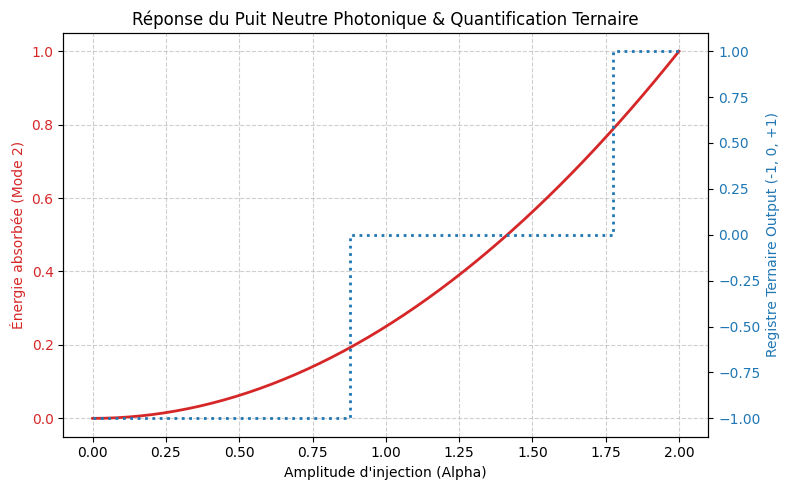

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Simulateur photonique à 3 modes
dev = qml.device("default.gaussian", wires=3)

@qml.qnode(dev)
def puit_neutre_circuit(alpha):
    qml.Displacement(alpha, 0.0, wires=0)       # Injection d'énergie variable
    qml.Beamsplitter(np.pi / 4, 0.0, wires=[0, 1]) # Couplage Mode 0 -> Mode 1
    qml.Beamsplitter(np.pi / 4, 0.0, wires=[1, 2]) # Couplage Mode 1 -> Puit neutre (Mode 2)
    return qml.expval(qml.NumberOperator(2))

# Balayage de l'injection d'énergie
injections = np.linspace(0.0, 2.0, 50)
energies_puit = [puit_neutre_circuit(a) for a in injections]

# Quantification ternaire (-1, 0, +1)
def a_trit(valeur):
    if valeur < 0.2: return -1
    elif valeur < 0.8: return 0
    else: return 1

trits = [a_trit(e) for e in energies_puit]

# Traçage des courbes
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel("Amplitude d'injection (Alpha)")
ax1.set_ylabel("Énergie absorbée (Mode 2)", color=color)
ax1.plot(injections, energies_puit, color=color, linewidth=2, label="Énergie Puit Neutre")
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel("Registre Ternaire Output (-1, 0, +1)", color=color)
ax2.step(injections, trits, color=color, where='mid', linewidth=2, linestyle=':', label="État Ternaire")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Réponse du Puit Neutre Photonique & Quantification Ternaire")
fig.tight_layout()
plt.show()